# Pick any image based dataset from the list, implement the preprocessing and justify the preprocessing steps.

In [2]:
import os
import cv2
import numpy as np
import time 

from torchvision import transforms
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

DATASET_PATH = "dataset"      # root folder containing class subfolders
IMAGE_SIZE = (128, 128)       # resize all images to this size
AUGMENT = True                # set False if you don't want augmentation
AUG_PER_IMAGE = 2             # how many augmented versions per image

In [4]:

# ---------------------------------------------------------
# Define preprocessing transforms (Torch)
# ---------------------------------------------------------

augmentation_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

base_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

# ---------------------------------------------------------
# Load and preprocess dataset
# ---------------------------------------------------------

images = []
labels = []

classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d)) and not d.startswith('.')
])
label_encoder = LabelEncoder()
label_encoder.fit(classes)

print("Classes found:", classes)

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    print(f"Processing class: {class_name}")

    for filename in tqdm(os.listdir(class_path)):
        img_path = os.path.join(class_path, filename)

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Base preprocessing (resize + normalization)
        tensor_img = base_transform(img)
        images.append(tensor_img.numpy())
        labels.append(class_name)

        # Data augmentation
        if AUGMENT:
            for _ in range(AUG_PER_IMAGE):
                aug_img = augmentation_transforms(img)
                images.append(aug_img.numpy())
                labels.append(class_name)

# Convert to arrays
X = np.array(images)
y = label_encoder.transform(labels)

print("Preprocessing complete!")
print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", label_encoder.classes_)


Classes found: ['hatchback', 'motorcycle', 'pickup', 'sedan', 'suv']
Processing class: hatchback


100%|██████████| 181/181 [00:03<00:00, 55.76it/s]


Processing class: motorcycle


100%|██████████| 122/122 [00:02<00:00, 58.32it/s]


Processing class: pickup


...

Processing class: sedan


100%|██████████| 400/400 [00:05<00:00, 66.97it/s]


Processing class: suv


100%|██████████| 129/129 [00:01<00:00, 69.12it/s]


Preprocessing complete!
Dataset shape: (3930, 3, 128, 128)
Labels shape: (3930,)
Classes: ['hatchback' 'motorcycle' 'pickup' 'sedan' 'suv']


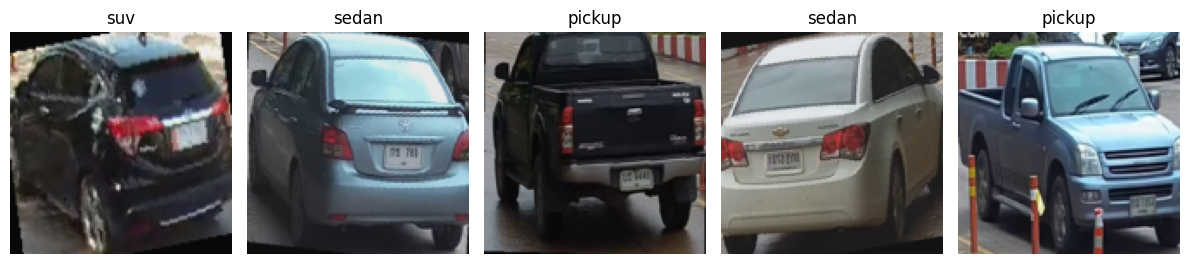

In [5]:
def show_images(X, y, label_encoder, num=5):
    plt.figure(figsize=(12, 6))
    
    for i in range(num):
        idx = np.random.randint(0, len(X))
        img = X[idx]

        # Convert from (C, H, W) → (H, W, C)
        img = np.transpose(img, (1, 2, 0))

        label = label_encoder.inverse_transform([y[idx]])[0]
        
        plt.subplot(1, num, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Display 5 images
show_images(X, y, label_encoder, num=5)


# Extract features and justify the methods used

In [6]:
def extract_hog_features(X):
    """
    X: numpy array of shape (N, C, H, W) or (N, H, W, C)
    Returns: HOG feature matrix of shape (N, num_features)
    """
    hog_features = []

    print("Extracting HOG features...")

    for i in tqdm(range(len(X))):

        img = X[i]

        # Convert from (C, H, W) -> (H, W, C) if needed
        if img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        # Convert image to grayscale because HOG works on single channel
        gray = rgb2gray(img)

        # Extract HOG descriptor
        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            transform_sqrt=True,
            feature_vector=True
        )

        hog_features.append(features)

    return np.array(hog_features)

In [7]:
X_hog = extract_hog_features(X)

print("HOG feature matrix shape:", X_hog.shape)

Extracting HOG features...


100%|██████████| 3930/3930 [00:14<00:00, 269.98it/s]


HOG feature matrix shape: (3930, 8100)


# Select features and justify the methods used.

Train shape: (3144, 8100)
Test shape: (786, 8100)
PCA reduced shape: (3144, 150)


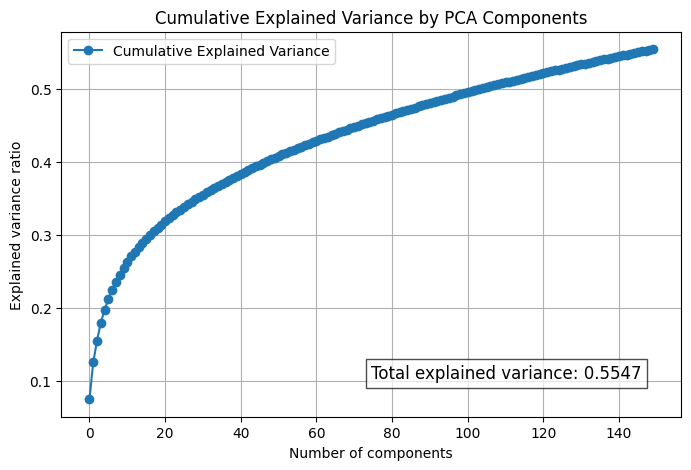

Total explained variance from PCA components: 0.554694


In [8]:
# ------------------------------------------------------------
# 1. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ------------------------------------------------------------
# 2. Scale features BEFORE PCA
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 3. PCA: fit on training data
# ------------------------------------------------------------

pca_components = 150      # You can tune this number
pca = PCA(n_components=pca_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA reduced shape: {X_train_pca.shape}")

# ------------------------------------------------------------
# 4. Plot explained variance + show total explained variance
# ------------------------------------------------------------

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
total_explained = np.sum(explained_var)

plt.figure(figsize=(8, 5))
plt.plot(cum_var, marker='o', label="Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of components")
plt.ylabel("Explained variance ratio")
plt.grid(True)

# Display total variance on the plot
plt.text(
    0.5, 0.1,
    f"Total explained variance: {total_explained:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.legend()
plt.show()

print(f"Total explained variance from PCA components: {total_explained:.6f}")



# Implement (using the selected features) one basic machine learning algorithm for classification and justify your choice 

Training SVM on PCA features...
Training time: 0.6017 seconds
Prediction time: 0.1857 seconds

Accuracy (PCA + SVM): 0.955470737913486

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       109
           1       0.97      1.00      0.99        73
           2       0.98      0.98      0.98       287
           3       0.95      0.98      0.97       240
           4       0.93      0.81      0.86        77

    accuracy                           0.96       786
   macro avg       0.95      0.94      0.94       786
weighted avg       0.96      0.96      0.95       786



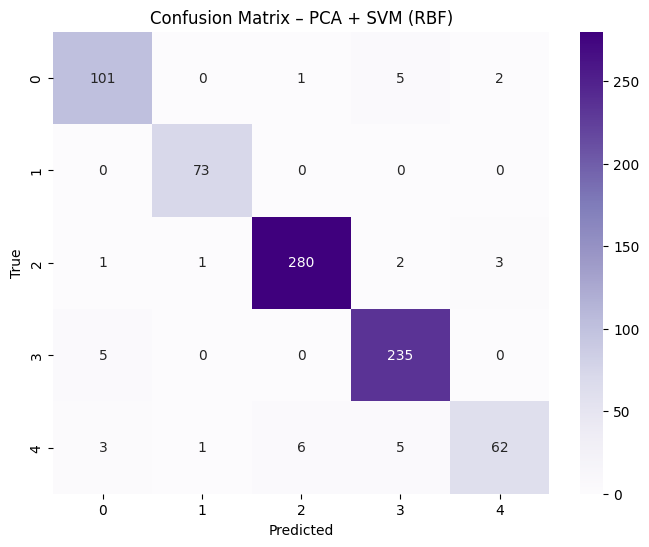

In [9]:

# ------------------------------------------------------------
# 5. Train SVM (RBF) on PCA features
# ------------------------------------------------------------

svm_pca = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

print("Training SVM on PCA features...")
start = time.time()
svm_pca.fit(X_train_pca, y_train)
end = time.time()


training_time = end - start
print(f"Training time: {training_time:.4f} seconds")

# ------------------------------------------------------------
# 6. Evaluate performance
# ------------------------------------------------------------
start = time.time()
y_pred_pca = svm_pca.predict(X_test_pca)
end = time.time()


prediction_time = end - start
print(f"Prediction time: {prediction_time:.4f} seconds")

accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("\nAccuracy (PCA + SVM):", accuracy_pca)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))

# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix – PCA + SVM (RBF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### Advanced Model Boosting med XGBoost

Training XGBoost on PCA features...
Training time: 8.9545 seconds
Prediction time: 0.0090 seconds

Accuracy (PCA + XGBoost): 0.8791348600508906

Classification Report:
              precision    recall  f1-score   support

   hatchback       0.92      0.66      0.77       109
  motorcycle       0.96      1.00      0.98        73
      pickup       0.89      0.96      0.92       287
       sedan       0.82      0.96      0.89       240
         suv       0.95      0.53      0.68        77

    accuracy                           0.88       786
   macro avg       0.91      0.82      0.85       786
weighted avg       0.89      0.88      0.87       786



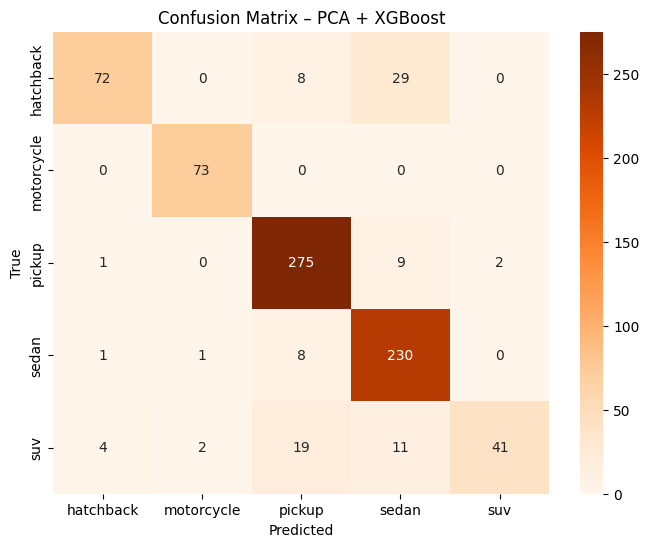

In [12]:
# ------------------------------------------------------------
# 5. Train XGBoost on PCA features
# ------------------------------------------------------------
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training XGBoost on PCA features...")
start = time.time()
xgb_model.fit(X_train_pca, y_train)
end = time.time()

training_time = end - start
print(f"Training time: {training_time:.4f} seconds")


# ------------------------------------------------------------
# 6. Evaluate performance
# ------------------------------------------------------------
start = time.time()
y_pred_xgb = xgb_model.predict(X_test_pca)
end = time.time()

prediction_time = end - start
print(f"Prediction time: {prediction_time:.4f} seconds")

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("\nAccuracy (PCA + XGBoost):", accuracy_xgb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))


# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – PCA + XGBoost")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### Advanced modelling bagging med Random forest

Training Random Forest on PCA features...
Training time: 1.4542 seconds
Prediction time: 0.0726 seconds

Accuracy (PCA + Random Forest): 0.8091603053435115

Classification Report:
              precision    recall  f1-score   support

   hatchback       0.92      0.45      0.60       109
  motorcycle       1.00      0.88      0.93        73
      pickup       0.77      0.97      0.86       287
       sedan       0.78      0.94      0.85       240
         suv       1.00      0.26      0.41        77

    accuracy                           0.81       786
   macro avg       0.90      0.70      0.73       786
weighted avg       0.84      0.81      0.78       786



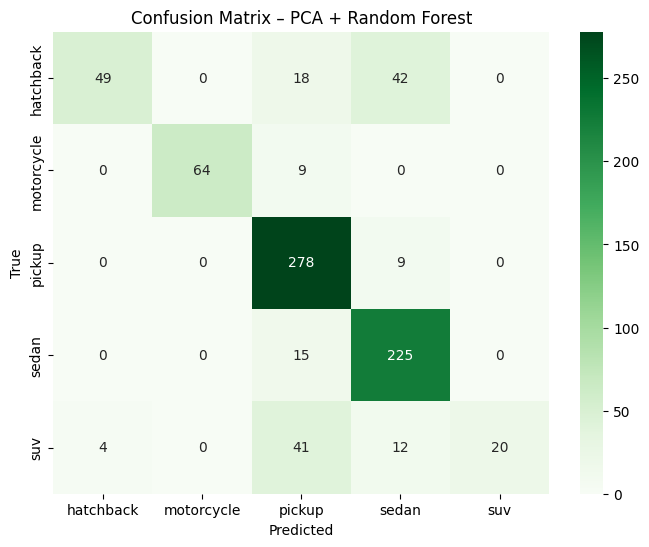

In [13]:
# ------------------------------------------------------------
# 5. Train Random Forest on PCA features
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,      # Number of trees (can tune)
    max_depth=None,        # Let trees grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',   # Typical good choice
    bootstrap=True,
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

print("Training Random Forest on PCA features...")
start = time.time()
rf_model.fit(X_train_pca, y_train)
end = time.time()

training_time = end - start
print(f"Training time: {training_time:.4f} seconds")


# ------------------------------------------------------------
# 6. Evaluate performance
# ------------------------------------------------------------
start = time.time()
y_pred_rf = rf_model.predict(X_test_pca)
end = time.time()

prediction_time = end - start
print(f"Prediction time: {prediction_time:.4f} seconds")

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nAccuracy (PCA + Random Forest):", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))


# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – PCA + Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### CNN

Starting CNN hyperparameter tuning...

Testing: lr=0.001, batch=32, dropout=0.3
Val Acc: 0.8931

Testing: lr=0.001, batch=32, dropout=0.5
Val Acc: 0.8906

Testing: lr=0.001, batch=64, dropout=0.3
Val Acc: 0.8155

Testing: lr=0.001, batch=64, dropout=0.5
Val Acc: 0.7379

Testing: lr=0.0005, batch=32, dropout=0.3
Val Acc: 0.8995

Testing: lr=0.0005, batch=32, dropout=0.5
Val Acc: 0.8868

Testing: lr=0.0005, batch=64, dropout=0.3
Val Acc: 0.8486

Testing: lr=0.0005, batch=64, dropout=0.5
Val Acc: 0.8321

Best params: (0.0005, 32, 0.3)
Best validation accuracy: 0.8994910941475827

Training final CNN...
Epoch 1/8 Loss: 0.1633
Epoch 2/8 Loss: 0.1077
Epoch 3/8 Loss: 0.0497
Epoch 4/8 Loss: 0.0338
Epoch 5/8 Loss: 0.0443
Epoch 6/8 Loss: 0.0246
Epoch 7/8 Loss: 0.0100
Epoch 8/8 Loss: 0.0126
Training time: 1765383419.06 seconds
Prediction time: 1.7433 seconds

CNN Accuracy: 0.916030534351145

Classification Report:
              precision    recall  f1-score   support

   hatchback       0.94      

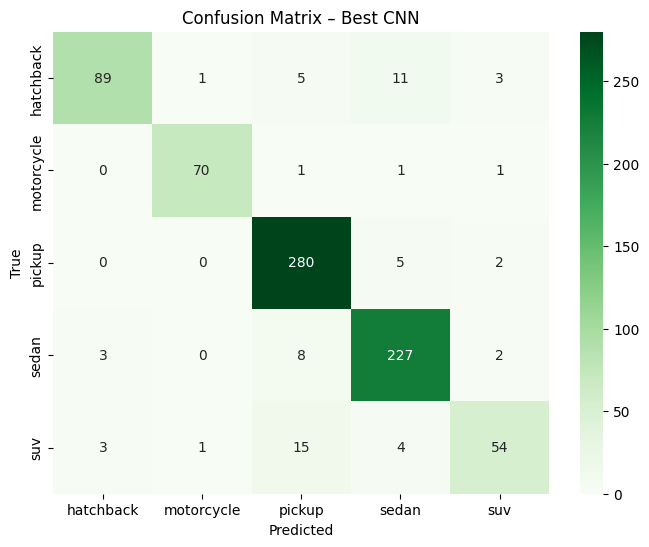

In [11]:
# ------------------------------------------------------------
# 5. CNN with Hyperparameter Tuning
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time

torch.manual_seed(42)

# Ensure tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# Train/test split
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_tensor, y_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_dataset = TensorDataset(X_train_cnn, y_train_cnn)
test_dataset  = TensorDataset(X_test_cnn,  y_test_cnn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(label_encoder.classes_)

# ------------------------------------------------------------
# CNN model
# ------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        flatten_dim = 64 * (IMAGE_SIZE[0] // 4) * (IMAGE_SIZE[1] // 4)
        self.classifier = nn.Sequential(
            nn.Linear(flatten_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "lr": [0.001, 0.0005],
    "batch_size": [32, 64],
    "dropout": [0.3, 0.5]
}

best_acc = 0
best_params = None
best_state  = None

print("Starting CNN hyperparameter tuning...\n")

# ------------------------------------------------------------
# Manual grid search (simple & readable)
# ------------------------------------------------------------
for lr in param_grid["lr"]:
    for bs in param_grid["batch_size"]:
        for dr in param_grid["dropout"]:

            print(f"Testing: lr={lr}, batch={bs}, dropout={dr}")

            train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
            test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False)

            model = SimpleCNN(num_classes, dropout=dr).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            # --- Train ---
            for epoch in range(4):  # quick epochs for tuning
                model.train()
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    optimizer.zero_grad()
                    loss = criterion(model(xb), yb)
                    loss.backward()
                    optimizer.step()

            # --- Validate ---
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = model(xb).argmax(1)
                    correct += (preds == yb).sum().item()
                    total += yb.size(0)

            acc = correct / total
            print(f"Val Acc: {acc:.4f}\n")

            if acc > best_acc:
                best_acc = acc
                best_params = (lr, bs, dr)
                best_state = model.state_dict()


print("Best params:", best_params)
print("Best validation accuracy:", best_acc)


# ------------------------------------------------------------
# 6. Train final CNN
# ------------------------------------------------------------
lr, bs, dr = best_params

print("\nTraining final CNN...")
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False)

model = SimpleCNN(num_classes, dropout=dr).to(device)
model.load_state_dict(best_state)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

start = time.time()

for epoch in range(8):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/8 Loss: {epoch_loss/len(train_loader):.4f}")

end = time.time()
print(f"Training time: {end:.2f} seconds")


# ------------------------------------------------------------
# 7. Evaluate model
# ------------------------------------------------------------
model.eval()
y_pred = []
y_true = []

start_pred = time.time()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(yb.numpy())

end_pred = time.time()

print(f"Prediction time: {end_pred - start_pred:.4f} seconds")
print("\nCNN Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


# ------------------------------------------------------------
# 8. Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix – Best CNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### XgBoost med masse crazy greier fra ChatGPT. Ikke nødvendig å se på denne!

In [14]:
# ----------------------------
# XGBoost: Randomized search + final fit + evaluation
# ----------------------------
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import time

# --- Safety checks / seed ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Ensure variables from previous cells exist
try:
    X_train_pca.shape
    X_test_pca.shape
    y_train.shape
    y_test.shape
except NameError as e:
    raise RuntimeError("Kjøre cellene som lager X_train_pca, X_test_pca, y_train, y_test først.") from e

# ----------------------------
# 1) Compute sample weights to reduce bias from class imbalance (multiclass)
# ----------------------------
classes_unique = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_train)
# map weights to each training sample
sample_weight = np.array([class_weights[np.where(classes_unique == yi)[0][0]] for yi in y_train])

# ----------------------------
# 2) Quick randomized hyperparameter search (not exhaustive — adjust n_iter if you want)
# ----------------------------
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

param_dist = {
    'n_estimators': [100, 200, 400, 800],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 1e-3, 1e-2, 0.1],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=25,                # change to 50-100 if you want more thorough search
    scoring='accuracy',
    cv=cv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)

print("Starting RandomizedSearchCV for XGBoost (this may take some minutes)...")
rs_start = time.time()
random_search.fit(X_train_pca, y_train)   # not passing sample_weight in the search to keep CV simple
rs_end = time.time()
print(f"RandomizedSearchCV done — elapsed {rs_end - rs_start:.1f}s")
print("Best params found:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# ----------------------------
# 3) Final model: use best params, fit with sample weights and early stopping on test set
# ----------------------------
best_params = random_search.best_params_.copy()

final_model = xgb.XGBClassifier(
    objective='multi:softprob',
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    **best_params
)

print("\nFitting final model with sample weights and early stopping (eval on test set)...")
fit_start = time.time()
final_model.fit(
    X_train_pca, y_train,
    sample_weight=sample_weight,
    eval_set=[(X_test_pca, y_test)],
    early_stopping_rounds=20,
    verbose=False
)
fit_end = time.time()
print(f"Final fit done — elapsed {fit_end - fit_start:.1f}s")
print("Best iteration (if available):", getattr(final_model, "best_iteration", None))

# ----------------------------
# 4) Evaluation
# ----------------------------
pred_start = time.time()
y_pred = final_model.predict(X_test_pca)
pred_end = time.time()
print(f"Prediction elapsed {pred_end - pred_start:.3f}s")

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy (XGBoost): {acc:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — XGBoost")
plt.show()

# ----------------------------
# 5) Feature importance (PCA-components importance)
# ----------------------------
# We plot top-k important PCA components for interpretability
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = min(20, len(importances))

plt.figure(figsize=(10,5))
plt.bar(range(top_k), importances[indices[:top_k]])
plt.xticks(range(top_k), [f"PC{idx+1}" for idx in indices[:top_k]], rotation=45)
plt.title("Top PCA components by feature importance (XGBoost)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ----------------------------
# 6) Save model and scaler + pca for future use
# ----------------------------
model_path = "xgb_final_model.joblib"
joblib.dump({
    "model": final_model,
    "scaler": scaler,
    "pca": pca,
    "label_encoder": label_encoder
}, model_path)
print(f"Saved model+scaler+pca+label_encoder to {model_path}")


Starting RandomizedSearchCV for XGBoost (this may take some minutes)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits


C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [17:24:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV done — elapsed 273.8s
Best params found: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.001, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.5}
Best CV score: 0.869910941475827

Fitting final model with sample weights and early stopping (eval on test set)...


TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'